In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict,deque

In [13]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

In [5]:
url='https://raw.githubusercontent.com/martj42/international_results/master/shootouts.csv'
data=pd.read_csv(url)
data.head()

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


In [5]:
data.tail()

,date,home_team,away_team,winner,first_shooter
677,2026-06-06,Lithuania,Latvia,Lithuania,Lithuania
678,2026-06-29,Germany,Paraguay,Paraguay,Germany
679,2026-06-29,Netherlands,Morocco,Morocco,Netherlands
680,2026-07-03,Australia,Egypt,Egypt,Australia
681,2026-07-07,Switzerland,Colombia,Switzerland,Colombia


In [6]:
data['first_shooter']=np.where(data['first_shooter'].isna(),data['home_team'],data['first_shooter'])

In [7]:
data['first_shooter']

0            India
1      South Korea
2      South Korea
3         Thailand
4         Thailand
          ...     
677      Lithuania
678        Germany
679    Netherlands
680      Australia
681       Colombia
Name: first_shooter, Length: 682, dtype: str

In [8]:
name_map = {
    "German DR": "Germany",
    "West Germany": "Germany",
    "Zaire": "DR Congo",
}
data['home_team']=data['home_team'].replace(name_map)
data['away_team']=data['away_team'].replace(name_map)
data['first_shooter']=data['first_shooter'].replace(name_map)

## Feature engineering

This includes calculating ELO rating, previous shootout forms...

In [9]:
elo={}
K,BASE_ELO=32,1500
def get_elo(team):
    return elo.get(team,BASE_ELO)
# compute the winner
def expected_score(r_a, r_b):
    return 1 / (1 + 10 ** ((r_b - r_a) / 400))
# get their previous penalty shootouts
form=defaultdict(lambda: deque(maxlen=3)) # get the last three shootouts
home_elo_pre, away_elo_pre=[],[]
home_form_wins, away_form_wins=[],[]
first_shooter_home=[]
for _,row in data.iterrows():
    h,a=row["home_team"], row["away_team"]
    r_h,r_a=get_elo(h), get_elo(a)
    home_elo_pre.append(r_h)
    away_elo_pre.append(r_a)
    h_form, a_form= list(form[h]), list(form[a])
    home_form_wins.append(sum(h_form) / len(h_form) if h_form else 0.5)  # 0.5 neutral
    away_form_wins.append(sum(a_form) / len(a_form) if a_form else 0.5)
    winner=row['winner']
    w_h,w_a=0,0
    if winner==h:
        w_h=0
    else:
        w_a=1
    exp_h=expected_score(r_h, r_a)
    elo[h] = r_h + K * (w_h - exp_h)
    elo[a] = r_a + K * ((1 - w_a) - (1 - exp_h))
    form[h].append(w_h)
    form[a].append(1-w_h)
    first_shooter_home.append(1 if row['first_shooter']==h else 0)
data['home_elo']=home_elo_pre
data["away_elo"]=away_elo_pre
data["elo_diff"]=data["home_elo"]-data['away_elo']
data["home_form_wins"]=home_form_wins
data["away_form_wins"]=away_form_wins
data['is_first_shooter_home']=first_shooter_home

Zambia           1289.048030
South Africa     1297.300580
Egypt            1307.500006
Argentina        1311.907323
Uruguay          1313.356230
Thailand         1317.200952
Iraq             1324.198209
Ivory Coast      1327.789831
Senegal          1338.058629
Indonesia        1340.844215
Iran             1343.370899
Cameroon         1347.032829
Kenya            1359.029136
United States    1360.248529
Nigeria          1361.284184
dtype: float64

In [10]:
def outcome(row):
    if pd.isna(row["home_team"]) or pd.isna(row["away_team"]) or pd.isna("winner"):
        return np.nan
    if row["winner"]==row["home_team"]:
        return 0 # home win
    else:
        return 1 # away win
data["result"]=data.apply(outcome,axis=1)

In [14]:
features= ["home_elo","away_elo","elo_diff","home_form_wins","away_form_wins",'is_first_shooter_home']
X=data[features]
y=data['result']
X_train,X_test,y_train,y_test= train_test_split(X,y,random_state=32,test_size=0.2)


# Use XGBoostClassifier to fit our model

In [ ]:
# model = XGBClassifier(
#     n_estimators=300,
#     max_depth=4,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     objective="multi:softmax",
#     num_class=3,
#     eval_metric="mlogloss",
#     random_state=42,
# )
# model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load

In [15]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=300,        # Same as XGBoost
    max_depth=4,             # Same as XGBoost
    random_state=42,
    # Additional Random Forest parameters
    min_samples_split=2,     # Minimum samples to split a node
    min_samples_leaf=1,      # Minimum samples at leaf node
    max_features='sqrt',     # Number of features for best split
    bootstrap=True,          # Use bootstrap samples
    oob_score=False,         # Out-of-bag score
    n_jobs=-1                # Use all CPU cores
)
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total nu

In [16]:
pred = model.predict(X_test)
proba = model.predict_proba(X_test)

print(f"XGBoost accuracy : {accuracy_score(y_test, pred):.3f}")
# print(f"XGBoost log loss : {log_loss(y_test, proba):.3f}")


XGBoost accuracy : 0.504


Confusion Matrix:
[[59 10]
 [58 10]]



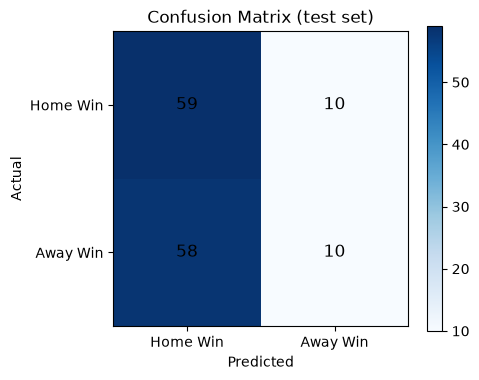

In [17]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))
print()

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")

labels = ["Home Win", "Away Win"]

ax.set_xticks(range(2))
ax.set_xticklabels(labels)
ax.set_yticks(range(2))
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

# Add text annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.title("Confusion Matrix (test set)")
plt.colorbar(im)
plt.tight_layout()
plt.show()

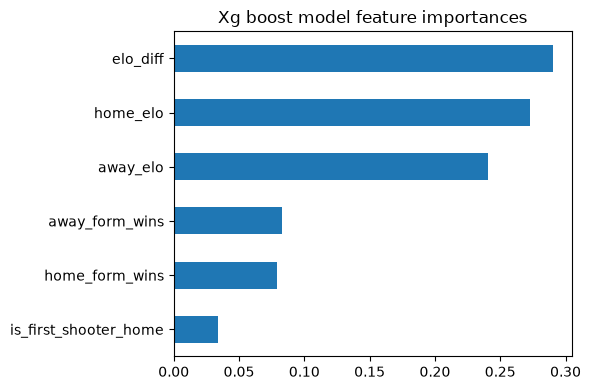

In [18]:
importances=pd.Series(model.feature_importances_,index=features).sort_values()
importances.plot(kind='barh',figsize=(6,4),title="Xg boost model feature importances")
plt.tight_layout()
plt.show()